In [1]:
import sys 
sys.path.append('../..')

import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.dynamics import DoubleIntegrator, KinematicUnicycle

from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.obstacle import Obstacle
from time_opt_erg_lib.cbf import constr2CBF
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck, recon_from_fourier
# from time_opt_erg_lib.target_distribution import TargetDistribution
from time_opt_erg_lib.cbf_utils import sdf2cbf
from IPython.display import clear_output
import matplotlib.pyplot as plt

from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
import yaml
import pickle as pkl

from bayes_filter import BayesFilter


In [2]:
class CkDynamics(object):
    def __init__(self, basis, _bnds) -> None:
        self._bnds = _bnds
        self.basis = basis
        self._ck_state = np.zeros(basis.k_list.shape[0])
        self._t_curr = 0.0
        self.domain = np.meshgrid(
            *[
                np.linspace(_bnds[0][0],_bnds[0][1]),
                np.linspace(_bnds[1][0],_bnds[1][1])
            ]
        )
        self.x_vals = np.stack([X.ravel() for X in self.domain]).T
    def recon_ck(self):
        return recon_from_fourier(self._ck_state/self._t_curr, self.basis, self.basis.k_list, self.x_vals)
    def plot_ck(self):
        evals = self.recon_ck()
        plt.contour(self.domain[0], self.domain[1], evals.reshape(self.domain[0].shape))
    def step(self, x, dt):
        self._ck_state = self._ck_state + dt * self.basis.fk_vmap(x)
        self._t_curr = self._t_curr + dt

In [3]:
class TimeOptErgodicPlanner(object):
    def __init__(self, target_distribution, args) -> None:
        _bnds = args['wrksp_bnds']
        def emap(x):
            """ Function that maps states to workspace """
            return np.array([
                (x[0]-_bnds[0][0])/(_bnds[0][1]-_bnds[0][0]), 
                (x[1]-_bnds[1][0])/(_bnds[1][1]-_bnds[1][0])])
        vmap_emap = vmap(emap)

        basis           = BasisFunc(n_basis=[8,8], emap=emap)
        self._ck_dynamics = CkDynamics(basis, _bnds)
        self.basis = basis 
        erg_metric      = ErgodicMetric(basis)
        robot_model     = DoubleIntegrator()
        n,m = robot_model.n, robot_model.m
        args.update({
            'phik' : get_phik(target_distribution.evals, basis),
            'ck_state' : self._ck_dynamics._ck_state
        })
        # @jit
        def loss(params, args):
            tf  = params['tf']
            """ Traj opt loss function, not the same as erg metric """
            return tf

        def eq_constr(params, args):
            """ dynamic equality constriants """
            x = params['x']
            u = params['u']
            x0 = args['x0']
            xf = args['xf']
            tf = params['tf']
            N = args['N']
            dt = tf/N
            return np.vstack([
                x[0] - x0, 
                x[1:,:]-(x[:-1,:]+dt*vmap(robot_model.dfdt)(x[:-1,:], u[:-1,:])),
                (x[-1] - xf)*0
            ])

        def ineq_constr(params, args):
            """ inequality constraints"""
            x = params['x']
            u = params['u']
            phik    = args['phik']
            tf      = params['tf']
            N       = args['N']
            dt      = tf/N
            e = vmap_emap(x)
            ck = (get_ck(x, basis, tf, dt) * tf + args['ck_state'])/(args['t_curr'] + tf)
            _erg_ineq = [np.array([erg_metric(ck, phik) - args['erg_ub'], -tf])]
            _ctrl_box = [(np.abs(u) - 1.).flatten()]
            _expl_box = [(-e).flatten(), (e-1.0).flatten()]
            return np.concatenate(_erg_ineq + _ctrl_box + _expl_box)


        x = np.linspace(args['x0'], args['xf'], args['N'], endpoint=True)
        u = np.zeros((args['N'], robot_model.m))
        init_sol = {'x': x, 'u' : u, 'tf': np.array(10.0)}
        self.solver = AugmentedLagrangeSolver(
                        init_sol,
                        loss, 
                        eq_constr, 
                        ineq_constr, 
                        args, 
                        step_size=1e-3,
                        c=10.0)
    def update_plan(self, args, max_iter=10_000):
        self.solver.solve(args, max_iter=max_iter)
        return self.solver.get_solution()



In [6]:
args = {
    'N' : 50, 
    'x0' : np.array([0., 0.1, 0.,0.]),
    'xf' : np.array([.9, .9, 0., 0.]),
    'erg_ub' : 0.1,
    'wrksp_bnds' : np.array([[-2.,2.],[-2.,2.]]), 
    't_curr' : 0, 
    'tf' : 10.0
}

def meas_model(p, x):
    return np.linalg.norm(x-p + 1e-3)
    # return np.arctan2(p[1]-x[1], (p[0]-x[0] + 1e-3))

target_distribution = BayesFilter(meas_model, lambda x: 1.0, args['wrksp_bnds'])
robot = DoubleIntegrator()
planner = TimeOptErgodicPlanner(target_distribution, args)

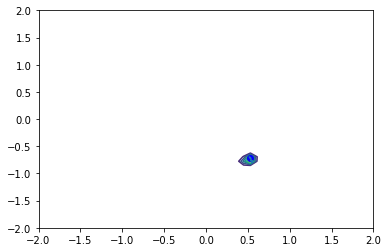

KeyboardInterrupt: 

In [7]:
_distractor_p = np.array([0.,0.])
_true_p = np.array([.5, -0.75])
_robot_state = np.array(args['x0'])
dt_list = []

for _ in range(100):
    planner.solver.reset()
    sol = planner.update_plan(args)
    _dt = sol['tf']/args['N']
    dt_list.append
    _robot_state = _robot_state + _dt * robot.dfdt(_robot_state, sol['u'][0])
    planner._ck_dynamics.step(_robot_state, _dt)
    args.update({
        'x0': _robot_state,
        'ck_state' : planner._ck_dynamics._ck_state, 
        't_curr' : planner._ck_dynamics._t_curr
    })
    _y = meas_model(_true_p, _robot_state[:2]) + onp.random.normal(0., 0.2)
    # _y_distract = meas_model(_robot_state[:2], _distractor_p) + onp.random.uniform(0., 0.1)
    target_distribution.update_prior(_robot_state[:2], _y)
    # target_distribution.update_prior(_robot_state[:2], _y_distract)
    target_distribution.update_eid()
    args.update({
        'phik' : get_phik(target_distribution.evals, planner.basis)
    })
    clear_output(wait=True)
    target_distribution.plot_eid()
    # target_distribution.plot_prior()
    # planner._ck_dynamics.plot_ck()
    plt.plot(sol['x'][0,0], sol['x'][0,1], 'bo')
    plt.plot(sol['x'][:,0], sol['x'][:,1])
    plt.show()

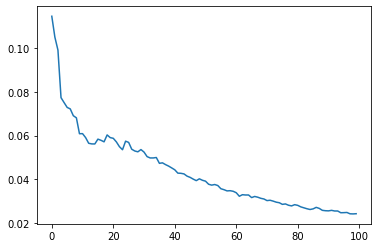

In [11]:
plt.plot(dt_list)

In [7]:
planner._ck_dynamics._t_curr

Array(7.463266, dtype=float32, weak_type=True)

In [10]:
planner._ck_dynamics._t_curr

Array(24.294024, dtype=float32, weak_type=True)